In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

<span style="font-size:14px">

### Filter Cavity Pole (Bandwidth)

For a filter cavity of length $L_2$, the pole frequency (half-width at half-maximum) is modeled as

$$
\gamma(\phi)
=
\frac{c}{8\pi L_2}
\left[
\epsilon + T_{\text{eff}}(\phi)
\right]
$$

where $\epsilon$ represents fixed round-trip loss (for example from the end mirror), and

$$
T_{\text{eff}}(\phi)
=
\frac{(1-R_1)(1-R_2)}
{1 - 2\sqrt{R_1R_2}\cos\phi + R_1R_2}.
$$

### Phase Tuning with Temperature

The etalon phase depends on temperature through both thermal expansion and the thermo-optic effect:

$$
\phi = \frac{4\pi n L_1}{\lambda_0}.
$$

Taking the temperature derivative,

$$
\frac{d\phi}{dT}
=
\frac{4\pi L_1}{\lambda_0}
\left(
n\alpha + \frac{dn}{dT}
\right),
$$

where  
- $\alpha$ is the linear thermal expansion coefficient and  
- $dn/dT$ is the thermo-optic coefficient of fused silica.

### Bandwidth Tunability

Using the chain rule, the thermal tunability of the cavity pole is

$$
\frac{d\gamma}{dT}
=
\frac{c}{8\pi L_2}
\frac{dT_{\text{eff}}}{d\phi}
\frac{d\phi}{dT}.
$$

The phase derivative of the effective transmissivity is

$$
\frac{dT_{\text{eff}}}{d\phi}
=
-\frac{(1-R_1)(1-R_2)\,2\sqrt{R_1R_2}\sin\phi}
{\left(1 - 2\sqrt{R_1R_2}\cos\phi + R_1R_2\right)^2}.
$$

Combining terms,

$$
\frac{d\gamma}{dT}
=
\frac{c}{8\pi L_2}
\left[
-\frac{(1-R_1)(1-R_2)\,2\sqrt{R_1R_2}\sin\phi}
{\left(1 - 2\sqrt{R_1R_2}\cos\phi + R_1R_2\right)^2}
\right]
\left[
\frac{4\pi L_1}{\lambda_0}
\left(
n\alpha + \frac{dn}{dT}
\right)
\right].
$$

### Quadrature Operation

Maximum linear tunability occurs near quadrature,

$$
\phi \approx \frac{\pi}{2}.
$$

At this operating point:
- $\sin\phi$ is maximized,
- the pole frequency varies approximately linearly with temperature,
- higher-order nonlinearities are minimized.

This is the preferred operating point for thermally tuning the filter cavity bandwidth.
</span>


In [2]:
# --- Choose parameters (edit these) ---
lambda0 = 1064e-9
f0 = 3e8 / lambda0

# R1 = 0.976
# R2 = 0.976
R1 = 0.90
R2 = 0.90
R3 = 0.998
L1 = 0.005966
L2 = 0.150

d = L1        # substrate thickness (m)
L = L2         # air gap to end mirror (m)
n = 1.4496

r1, r2 = np.sqrt(R1), np.sqrt(R2)
t1, t2 = np.sqrt(1-R1), np.sqrt(1-R2)
r3 = np.sqrt(R3)
t3 = np.sqrt(1-R3)

# --- Frequency sweep settings ---
span_MHz = 1000   # plot window half-span in MHz
N = 20001
df = np.linspace(-span_MHz*1e6, span_MHz*1e6, N)
freqs = f0 + df

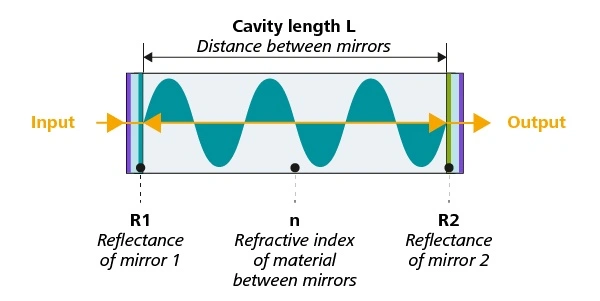

<span style="font-size:14px">

### Etalon + Long Cavity

This model describes the complex field reflection and transmission of a system consisting of

1. A solid etalon formed by two partially reflecting surfaces
2. A long propagation cavity of length $L$
3. A terminating end mirror with amplitude reflectivity $r_3$

All quantities are treated at the **field level**, with frequency dependence retained explicitly.

### Definitions

- Optical angular frequency:
  $$
  k = \frac{2\pi f}{c}
  $$

- Etalon round-trip phase:
  $$
  \delta = 2 k n d
  $$

- Long cavity round-trip phase:
  $$
  \theta = 2 k L
  $$

All reflectivities $r_i$ and transmissivities $t_i$ are **amplitude** coefficients.

### Etalon Transmission

The complex field transmission of the etalon is

$$
t_{\mathrm{et}}(f)
=
\frac{
t_1 t_2 e^{i\delta/2}
}{
1 - r_1 r_2 e^{i\delta}
}
$$

This corresponds to the coherent sum of all multiple internal reflections inside the solid spacer.

### Etalon Reflection from the Left

The effective reflection coefficient seen from the left side of the etalon is

$$
r_{\mathrm{et,L}}(f)
=
r_1
+
\frac{
t_1^2 r_2 e^{i\delta}
}{
1 - r_1 r_2 e^{i\delta}
}
$$

This includes the prompt reflection from surface 1 and all internal etalon contributions.

### Etalon Reflection from the Right

The effective reflection coefficient seen from the right side is

$$
r_{\mathrm{et,R}}(f)
=
r_2
+
\frac{
t_2^2 r_1 e^{i\delta}
}{
1 - r_1 r_2 e^{i\delta}
}
$$

This quantity acts as the **input coupler** for the long cavity.

### Total Reflection of Three-Surface System

The total reflected field from the full system is

$$
r_{\mathrm{tot}}(f)
=
r_{\mathrm{et,L}}
+
\frac{
t_{\mathrm{et}}^2 r_3 e^{i\theta}
}{
1 - r_{\mathrm{et,R}} r_3 e^{i\theta}
}
$$

This expression describes an effective Fabry–Perot cavity whose input coupler is the etalon itself.

### Total Transmission of Three-Surface System

The transmitted field through the full system is

$$
t_{\mathrm{tot}}(f)
=
\frac{
t_{\mathrm{et}}\, t_3\, e^{i k L}
}{
1 - r_{\mathrm{et,R}} r_3 e^{i\theta}
}
$$

The factor $e^{i k L}$ accounts for one-way propagation through the long cavity.

### Power Transmittance

The measurable transmitted power is

$$
T_{\mathrm{tot}}(f)
=
\left| t_{\mathrm{tot}}(f) \right|^2
$$

### Notes

- The etalon modifies the **effective reflectivity and transmissivity** seen by the long cavity
- The long cavity resonance condition is set by $\theta = 2 k L$
- The etalon phase $\delta$ controls coupling strength and cavity bandwidth
- All frequency-dependent interference effects are retained exactly

<span style="font-size:14px">

In [3]:
c = 299792458.0
twopi = 2*np.pi

# --- Complex model that depends on frequency f (Hz) ---

def t_et_f(t1, t2, r1, r2, d, f, n=1.4496):
    k = twopi * f / c
    delta = 2 * k * n * d
    num = t1 * t2 * np.exp(1j * delta / 2)
    denom = 1 - r1 * r2 * np.exp(1j * delta)
    return num / denom

def r_et_L_f(t1, t2, r1, r2, d, f, n=1.4496):
    k = twopi * f / c
    delta = 2 * k * n * d
    num = (t1**2) * r2 * np.exp(1j * delta)
    denom = 1 - r1 * r2 * np.exp(1j * delta)
    return r1 + num / denom

def r_et_R_f(t1, t2, r1, r2, d, f, n=1.4496):
    k = twopi * f / c
    delta = 2 * k * n * d
    num = (t2**2) * r1 * np.exp(1j * delta)
    denom = 1 - r1 * r2 * np.exp(1j * delta)
    return r2 + num / denom

def r_tot_f(t1, t2, r1, r2, r3, d, L, f, n=1.4496):
    k = twopi * f / c
    theta = 2 * k * L

    t_amp = t_et_f(t1, t2, r1, r2, d, f, n)
    rL = r_et_L_f(t1, t2, r1, r2, d, f, n)
    rR = r_et_R_f(t1, t2, r1, r2, d, f, n)

    num = (t_amp**2) * r3 * np.exp(1j * theta)
    denom = 1 - rR * r3 * np.exp(1j * theta)
    return rL + num / denom

def t_tot_f(t1, t2, r1, r2, r3, t3, d, L, f, n=1.4496):
    """Complex field transmission through etalon + long cavity + end mirror."""
    k = twopi * f / c
    theta = 2 * k * L

    t_amp = t_et_f(t1, t2, r1, r2, d, f, n)
    rR = r_et_R_f(t1, t2, r1, r2, d, f, n)

    # one-way propagation factor is exp(i k L)
    prop = np.exp(1j * k * L)

    denom = 1 - rR * r3 * np.exp(1j * theta)
    return (t_amp * t3 * prop) / denom

def T_tot_f(t1, t2, r1, r2, r3, t3, d, L, f, n=1.4496):
    """Power transmittance through full three-surface system."""
    return np.abs(t_tot_f(t1, t2, r1, r2, r3, t3, d, L, f, n))**2


In [4]:
# --- Compute r(f) ---
r = np.array([r_tot_f(t1, t2, r1, r2, r3, d, L, f, n) for f in freqs], dtype=complex)

Rrefl = np.abs(r)**2
phase = np.unwrap(np.angle(r))

# Optional: group delay (seconds)
omega = twopi * freqs
tau_g = np.gradient(phase, omega)

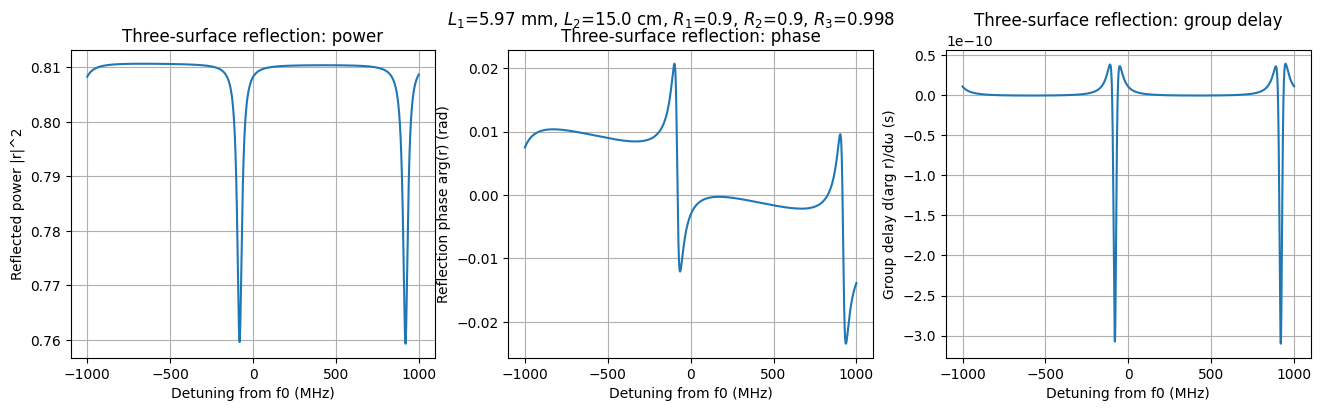

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=False)


# --- Plot reflected power ---
axes[0].plot(df/1e6, Rrefl)
axes[0].set_xlabel("Detuning from f0 (MHz)")
axes[0].set_ylabel("Reflected power |r|^2")
axes[0].set_title("Three-surface reflection: power")
axes[0].grid(True)

# --- Plot reflection phase ---
axes[1].plot(df/1e6, phase)
axes[1].set_xlabel("Detuning from f0 (MHz)")
axes[1].set_ylabel("Reflection phase arg(r) (rad)")
axes[1].set_title("Three-surface reflection: phase")
axes[1].grid(True)

# --- Plot group delay (optional) ---
axes[2].plot(df/1e6, tau_g)
axes[2].set_xlabel("Detuning from f0 (MHz)")
axes[2].set_ylabel("Group delay d(arg r)/dω (s)")
axes[2].set_title("Three-surface reflection: group delay")
axes[2].grid(True)

fig.suptitle(f"$L_1$={L1*1e3:.2f} mm, $L_2$={L2*1e2:.1f} cm, $R_1$={R1}, $R_2$={R2}, $R_3$={R3}")

plt.show()

Resonance freq (Hz): 281955806918045.06  detuning (MHz): 919.7


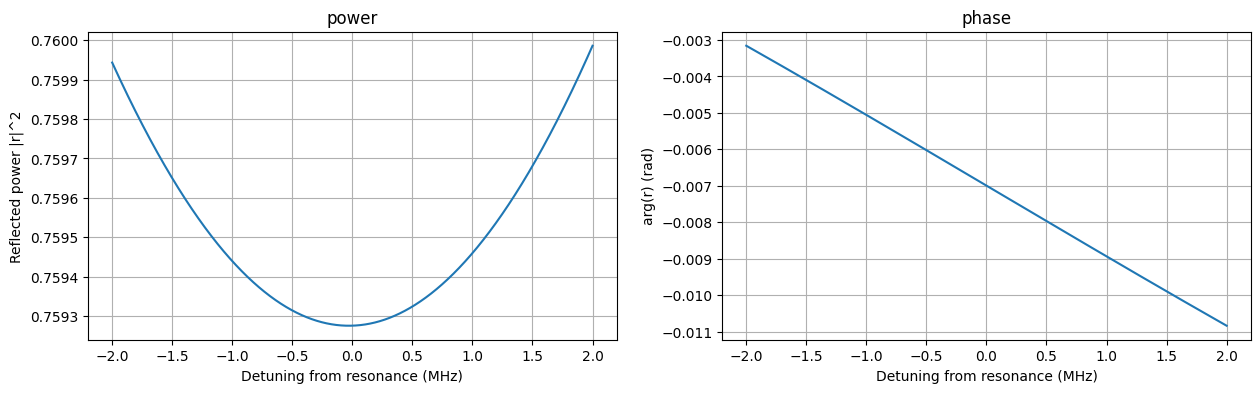

In [6]:
# pick one dip to zoom on: find the minimum |r|^2 in your current sweep
idx = np.argmin(Rrefl)
f_res = freqs[idx]
print("Resonance freq (Hz):", f_res, " detuning (MHz):", df[idx]/1e6)

# now do a narrow sweep around that resonance
span_zoom_MHz = 2.0
N_zoom = 20001
df_zoom = np.linspace(-span_zoom_MHz*1e6, span_zoom_MHz*1e6, N_zoom)
freqs_zoom = f_res + df_zoom

r_zoom = np.array([r_tot_f(t1, t2, r1, r2, r3, d, L, f, n) for f in freqs_zoom], dtype=complex)
R_zoom = np.abs(r_zoom)**2
phase_zoom = np.unwrap(np.angle(r_zoom))

fig2, axes2 = plt.subplots(1, 2, figsize=(15, 4), sharex=False)
axes2[0].plot(df_zoom/1e6, R_zoom)
axes2[0].set_xlabel("Detuning from resonance (MHz)")
axes2[0].set_ylabel("Reflected power |r|^2")
axes2[0].set_title("power")
axes2[0].grid(True)

axes2[1].plot(df_zoom/1e6, phase_zoom)
axes2[1].set_xlabel("Detuning from resonance (MHz)")
axes2[1].set_ylabel("arg(r) (rad)")
axes2[1].set_title("phase")
axes2[1].grid(True)

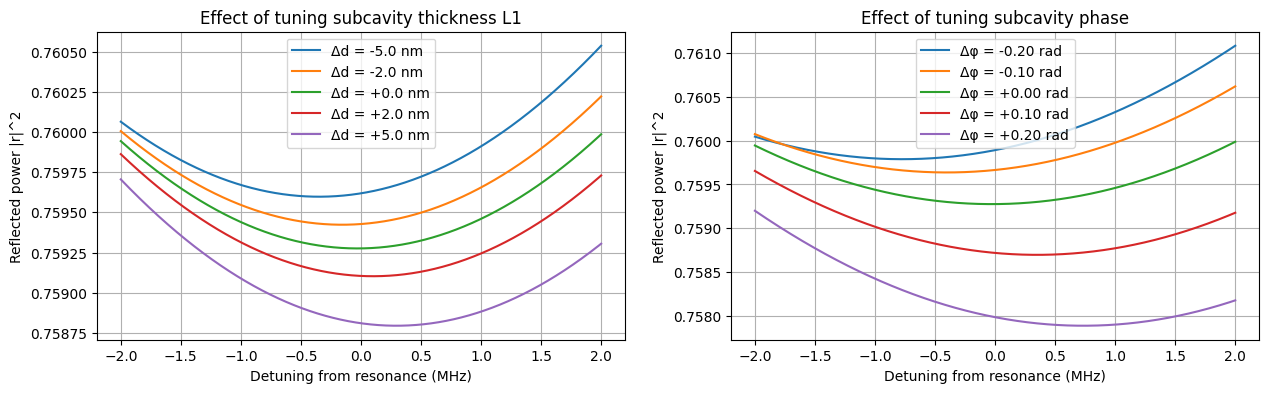

In [7]:
d0 = L1  # base thickness

# Small thickness changes (meters)
deltas = np.array([-5, -2, 0, 2, 5]) * 1e-9   # nm-scale steps

fig3, axes3 = plt.subplots(1, 2, figsize=(15, 4), sharex=False)

for dd in deltas:
    d = d0 + dd
    r_zoom = np.array([r_tot_f(t1, t2, r1, r2, r3, d, L, f, n) for f in freqs_zoom], dtype=complex)
    R_zoom = np.abs(r_zoom)**2

    axes3[0].plot(df_zoom/1e6, R_zoom, label=f"Δd = {dd*1e9:+.1f} nm")

axes3[0].set_xlabel("Detuning from resonance (MHz)")
axes3[0].set_ylabel("Reflected power |r|^2")
axes3[0].set_title("Effect of tuning subcavity thickness L1")
axes3[0].legend()
axes3[0].grid(True)

# Effective phase offsets
phi_offsets = np.array([-0.2, -0.1, 0.0, 0.1, 0.2])  # radians

for dphi in phi_offsets:
    # Equivalent thickness shift
    d = d0 + dphi * lambda0 / (4*np.pi*n)

    r_zoom = np.array([r_tot_f(t1, t2, r1, r2, r3, d, L, f, n) for f in freqs_zoom], dtype=complex)
    R_zoom = np.abs(r_zoom)**2

    axes3[1].plot(df_zoom/1e6, R_zoom, label=f"Δφ = {dphi:+.2f} rad")

axes3[1].set_xlabel("Detuning from resonance (MHz)")
axes3[1].set_ylabel("Reflected power |r|^2")
axes3[1].set_title("Effect of tuning subcavity phase")
axes3[1].legend()
axes3[1].grid(True)


In [28]:
def plot_bw_expansion(t1, t2, r1, r2, r3, t3, d, L, lambda0=1064.999e-9):

    nu0 = 3e8 / lambda0              
    #Frequency detuning (Δν from -150 MHz to 150 MHz)
    dnu_arr = np.linspace(-600e6, -100e6, 1000)
    nu = nu0+dnu_arr

    baseline_bw, bw_expansion, dL1_dT, dgamma_dL1 = BW_tunability(d,L,r1,r2,r3)
    print(f"L1 : {d*1e3:.3f} mm, Pole: {baseline_bw} Hz, Bandwidth Tunability: {bw_expansion} Hz/°C")

    # 2. Plot multiple temperature detunings
    plt.figure(figsize=(10,6))
    dL1_arr = [dL1_dT * T for T in np.arange(0, 11)]
    for dL1 in dL1_arr:
        T_tot = T_tot_f(t1, t2, r1, r2, r3, t3, d+dL1, L, nu)
        plt.semilogy(
            dnu_arr * 1e-6,
            T_tot,
            label=(
                f"$L_1$={(d + dL1)*1e3:.6f} mm, "
                f"$\gamma$={(baseline_bw + dgamma_dL1*dL1)/1e3:.1f} kHz"
            )
        )

    # 3. Labels & legend
    plt.xlabel("Frequency detuning $\\Delta\\nu$ [MHz]")
    plt.ylabel("Transmitted Power [arb. units]")
    plt.title(
        f"Power Transmission with Etalon Tuning\n"
        f"R1={r1**2:.4f}, R2={r2**2:.4f}, R3={r3**2:.4f}, L2={L2*1e2} cm"
    )
    plt.grid(True)
    plt.legend(loc='upper right')

    FSR   = 3e8 / (2 * L)           # free spectral range in Hz
    FSR_L2_MHz = FSR * 1e-6


    plt.text(
        0.01, 0.02,  # x and y in axis fraction
        f"FSR(L2) ≈ {FSR_L2_MHz:.3f} MHz\nPole: {baseline_bw/1e3:.3f} kHz\nTunability: {bw_expansion/1e3:.3f} kHz/C",
        transform=plt.gca().transAxes,
        fontsize=10,
        verticalalignment='bottom',
        horizontalalignment='left',
        bbox=dict(boxstyle="round,pad=0.3", facecolor='white', edgecolor='gray', alpha=0.8)
        )

    plt.tight_layout()
    plt.show()

def BW_tunability(d,L,r1,r2,r3,lambda0=1064e-9, tunability=0.55, heating_capacity=10, n=1.4496):
    """
    Returns:
        baseline_bw: Hz
        bw_expansion: Hz/K
        dL1_dT: m/K
        dgamma_dL1: Hz/m
    """
    R1,R2,R3 = r1**2, r2**2, r3**2
    c = 3e8
    prefactor = c/(8*np.pi*L)
    num = (1-R1)*(1-R2)
    denom = 1-2*np.sqrt(R1*R2)*np.cos(4*np.pi*n*d/lambda0)+R1*R2
    baseline_bw = prefactor*(num/denom + (1-R3))

    # Temperature Tunability
    dL1_dT = tunability*1e-6 * d 
    dTeff_dphi = -num*(2*np.sqrt(R1*R2)*np.sin(4*np.pi*n*d/lambda0))/(denom**2)
    dgamma_dL1 = prefactor * dTeff_dphi * (4*np.pi*n/lambda0)
    bw_expansion = dgamma_dL1 * dL1_dT

    return baseline_bw, bw_expansion, dL1_dT, dgamma_dL1 

10/90 Beamsplitter configuration

L1 : 5.966 mm, Pole: 571994.3493036547 Hz, Bandwidth Tunability: -21611.233513124513 Hz/°C


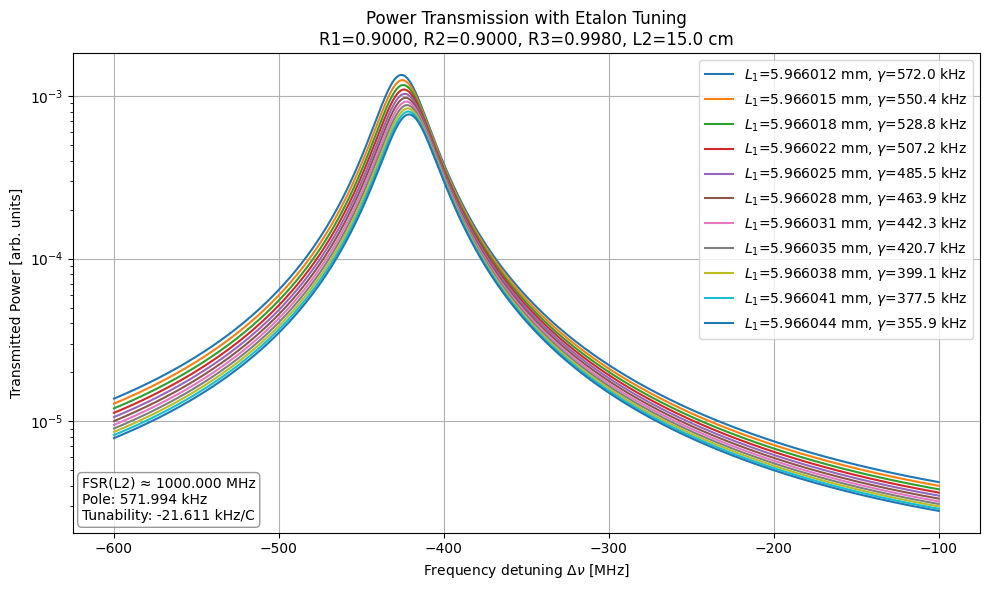

In [29]:
#10/90 Beam splitter configuration
plot_bw_expansion(t1, t2, r1, r2, r3, t3, d, L)

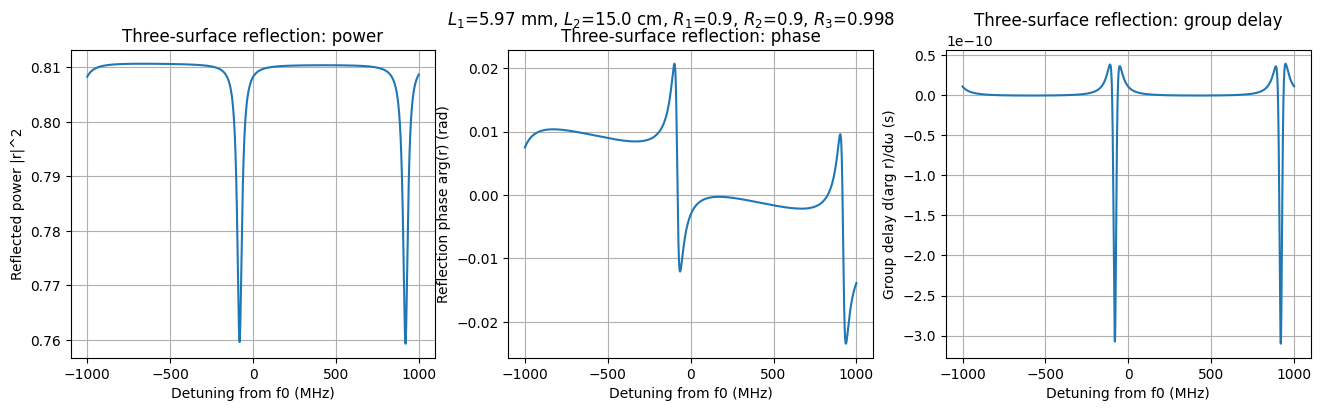

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=False)


# --- Plot reflected power ---
axes[0].plot(df/1e6, Rrefl)
axes[0].set_xlabel("Detuning from f0 (MHz)")
axes[0].set_ylabel("Reflected power |r|^2")
axes[0].set_title("Three-surface reflection: power")
axes[0].grid(True)

# --- Plot reflection phase ---
axes[1].plot(df/1e6, phase)
axes[1].set_xlabel("Detuning from f0 (MHz)")
axes[1].set_ylabel("Reflection phase arg(r) (rad)")
axes[1].set_title("Three-surface reflection: phase")
axes[1].grid(True)

# --- Plot group delay (optional) ---
axes[2].plot(df/1e6, tau_g)
axes[2].set_xlabel("Detuning from f0 (MHz)")
axes[2].set_ylabel("Group delay d(arg r)/dω (s)")
axes[2].set_title("Three-surface reflection: group delay")
axes[2].grid(True)

fig.suptitle(f"$L_1$={L1*1e3:.2f} mm, $L_2$={L2*1e2:.1f} cm, $R_1$={R1}, $R_2$={R2}, $R_3$={R3}")

plt.show()

L1 : 5.966 mm, Pole: 571994.3493036547 Hz, Bandwidth Tunability: -21611.233513124513 Hz/°C


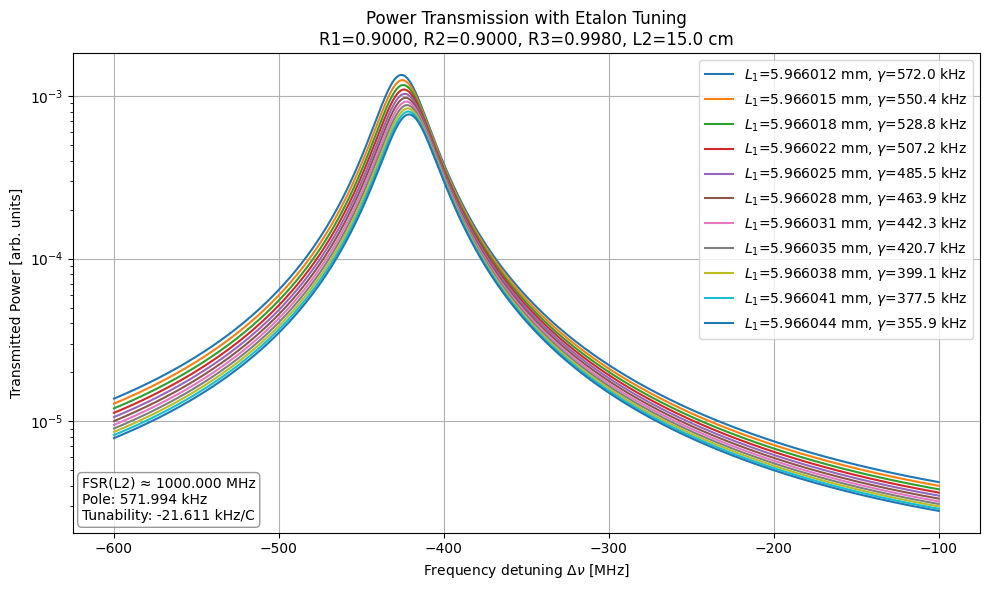

In [42]:
plot_bw_expansion(t1, t2, r1, r2, r3, t3, d, L)

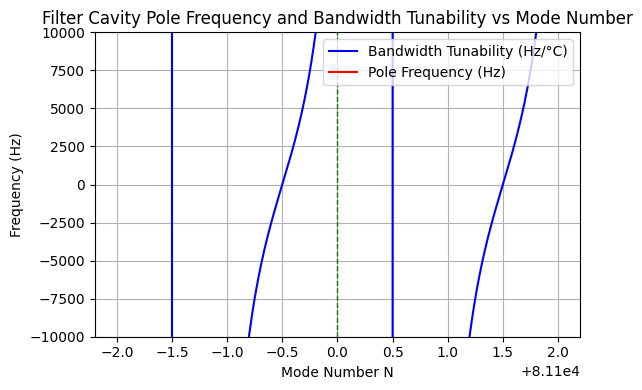

In [43]:
# Constants
tunability = 0.55e-6
sqrtR = np.sqrt(R1 * R2)

# Mode numbers N (integers)
N_vals = np.arange(81098, 81102,1e-3)

# --- Bandwidth Tunability Calculation ---
def bw_tuning(R1,R2,N_vals):
    phi = ((2 * N_vals + 3) / 2) * np.pi
    num = -(1 - R1) * (1 - R2) * 2 * sqrtR * np.sin(phi)
    denom = (1 - 2 * sqrtR * np.cos(phi) + R1 * R2)**2
    dTeff_dphi = num / denom

    L1 = ((2 * N_vals + 3) / 2) * lambda0 / 4 
    dL1_dT = tunability * L1
    prefactor = c / (4 * L2 * lambda0)
    dgamma_dL1 = prefactor * dTeff_dphi
    tune = dgamma_dL1 * dL1_dT
    return tune

# --- G(N) Calculation ---
def pole(R1, R2, L2, N_vals):
    phi = ((2 * N_vals + 3) / 2) * np.pi
    sqrtRb = np.sqrt(R1 * R2)
    numerator = (1 - R1) * (1 - R2)
    denominator = 1 - 2 * sqrtRb * np.cos(phi) + R1 * R2
    BW = c / (8 * np.pi * L2) * (1e-6 + (numerator / denominator))
    return BW

# --- Plotting ---
plt.figure(figsize=(6, 4))
plt.plot(N_vals, bw_tuning(R1,R2,N_vals), label='Bandwidth Tunability (Hz/°C)', color='blue')
plt.plot(N_vals, pole(R1,R2,L2,N_vals), label='Pole Frequency (Hz)', color='red')
plt.axvline(x=81100, color='green', linestyle='--', linewidth=1)
plt.xlabel('Mode Number N')
plt.ylabel('Frequency (Hz)')
plt.ylim(-1e4,1e4)
plt.title('Filter Cavity Pole Frequency and Bandwidth Tunability vs Mode Number')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [44]:
eps_loss = 1e-6     # fixed round-trip loss term, dimensionless

# Fused silica at ~1064 nm (update if you have measured values)
n = 1.4496
alpha = 0.55e-6     # 1/K (thermal expansion)
dn_dT = 8.6e-6      # 1/K (thermo-optic)

# ---------- Core model ----------
def Teff(phi, R1, R2):
    sqrtR = np.sqrt(R1 * R2)
    num = (1 - R1) * (1 - R2)
    den = 1 - 2 * sqrtR * np.cos(phi) + R1 * R2
    return num / den

def dTeff_dphi(phi, R1, R2):
    sqrtR = np.sqrt(R1 * R2)
    num = (1 - R1) * (1 - R2)
    den = 1 - 2 * sqrtR * np.cos(phi) + R1 * R2
    return -(num * (2 * sqrtR * np.sin(phi))) / (den**2)

def phi_from_L1(L1, n=n, lambda0=lambda0):
    return 4 * np.pi * n * L1 / lambda0

def pole_gamma(phi, R1, R2, L2, eps_loss=1e-6):
    # gamma in Hz
    return (c / (8 * np.pi * L2)) * (eps_loss + Teff(phi, R1, R2))

def dphi_dT(L1, n=n, alpha=alpha, dn_dT=dn_dT, lambda0=lambda0):
    # total phase tuning from expansion + thermo-optic
    return (4 * np.pi * L1 / lambda0) * (n * alpha + dn_dT)

def tunability_dgamma_dT(phi, L1, R1, R2, L2, eps_loss=1e-6):
    # dgamma/dT in Hz/K
    return (c / (8 * np.pi * L2)) * dTeff_dphi(phi, R1, R2) * dphi_dT(L1)

# ---------- Plot versus phase around quadrature ----------
phi0 = np.linspace(-np.pi, np.pi, 4000) + (np.pi / 2)  # centered near quadrature

gamma_vals = pole_gamma(phi0, R1, R2, L2, eps_loss=eps_loss)
tune_vals = tunability_dgamma_dT(phi0, L1, R1, R2, L2, eps_loss=eps_loss)

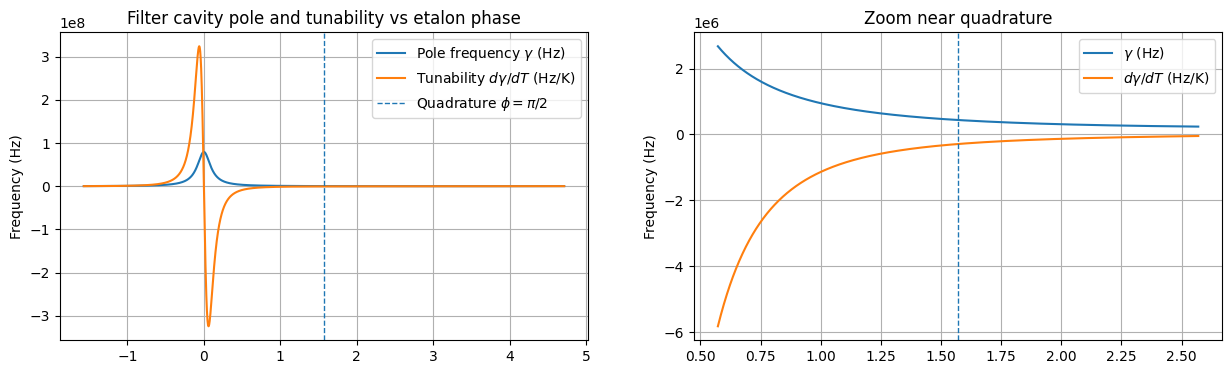

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4), sharex=False)

# ---------------- Panel 1: full phase scan ----------------
axes[0].plot(phi0, gamma_vals, label="Pole frequency $\\gamma$ (Hz)")
axes[0].plot(phi0, tune_vals, label="Tunability $d\\gamma/dT$ (Hz/K)")
axes[0].axvline(np.pi/2, linestyle="--", linewidth=1, label="Quadrature $\\phi=\\pi/2$")
axes[0].set_ylabel("Frequency (Hz)")
axes[0].set_title("Filter cavity pole and tunability vs etalon phase")
axes[0].grid(True)
axes[0].legend()

# ---------------- Panel 2: zoom near quadrature ----------------
phi_q = np.pi / 2
zoom_width = 1   # radians on each side

mask = (phi0 > phi_q - zoom_width) & (phi0 < phi_q + zoom_width)

axes[1].plot(phi0[mask], gamma_vals[mask], label="$\\gamma$ (Hz)")
axes[1].plot(phi0[mask], tune_vals[mask], label="$d\\gamma/dT$ (Hz/K)")
axes[1].axvline(phi_q, linestyle="--", linewidth=1)
axes[1].set_ylabel("Frequency (Hz)")
axes[1].set_title("Zoom near quadrature")
axes[1].grid(True)
axes[1].legend()


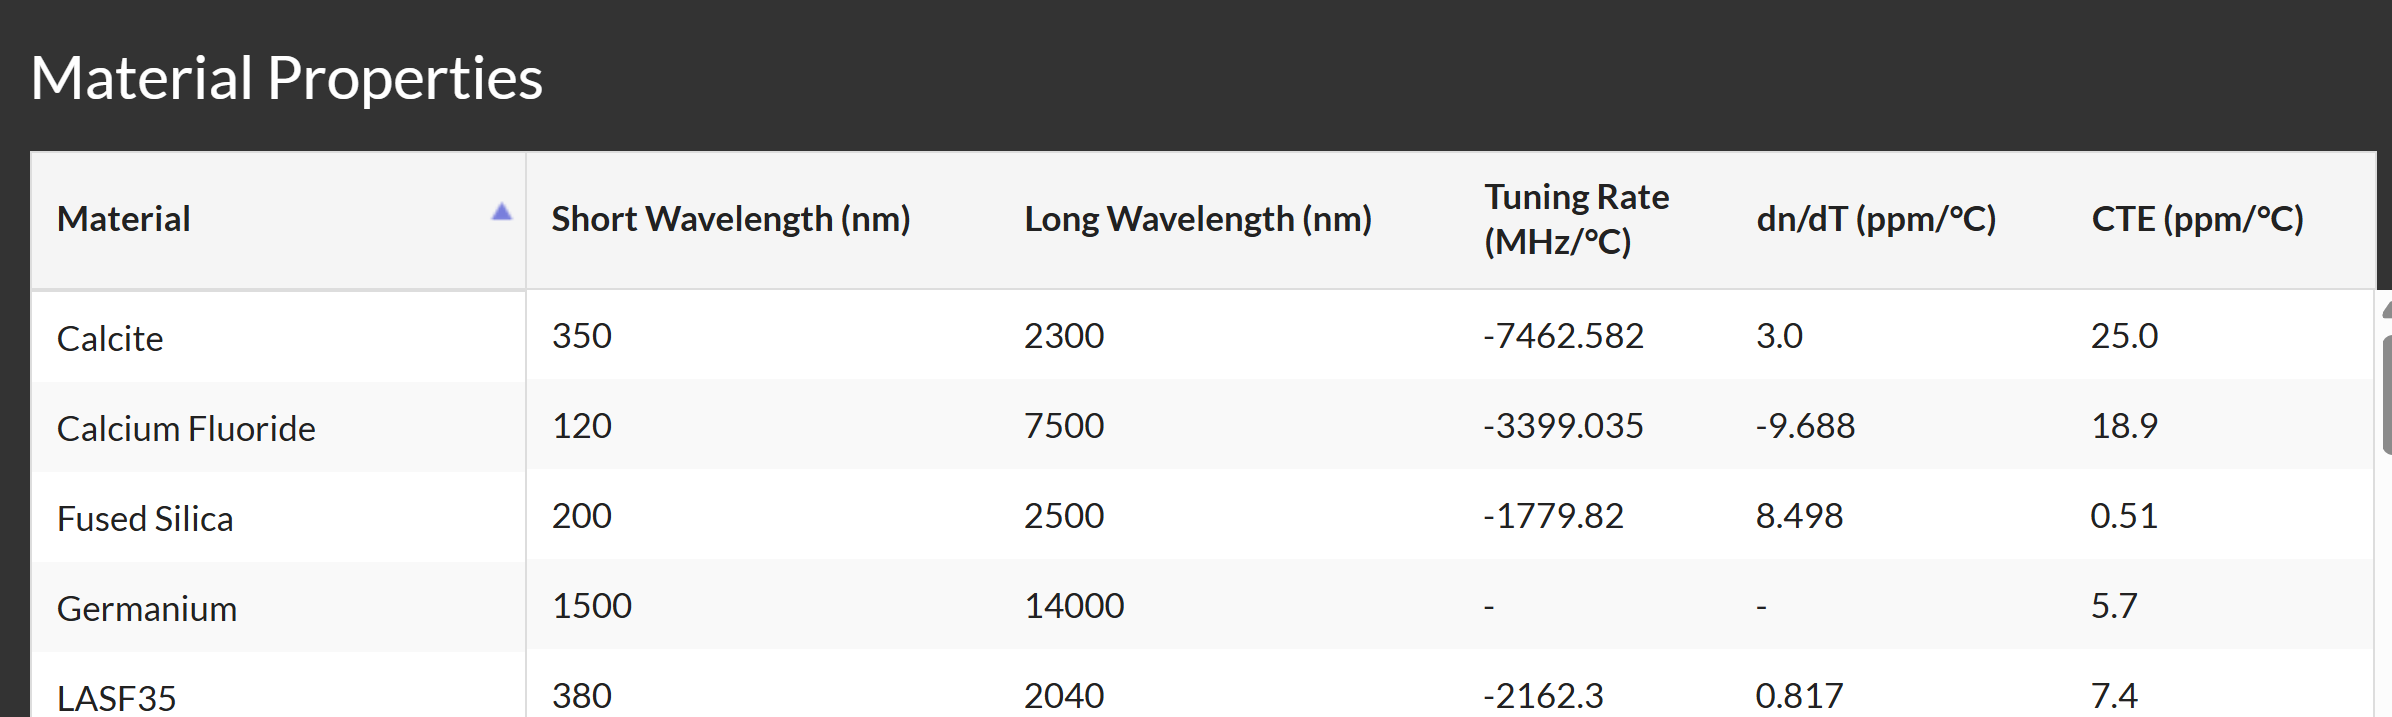